# Aggregation Global Analysis

In [1]:
def default_params(): 
    return {
        'current_model': 'M1', 
        'quantization': 'none', #['none',"int4", "int8", "float32", "float16"]
        'dataset': {
            'path': '/workspaces/CodeSmells/semeru-datasets/code_smells/extraction',
            'transformation': 'curated',
            'content_column': 'code',
            'sampling_size': 500,
        },
        'alignments_path': '/workspaces/CodeSmells/data/extension/alignments',

        'cache_dir': '/workspaces/CodeSmells/datax/hugging_face_cache',
    }
params = default_params()


#### Imports

In [2]:
import pandas as pd
import os
import time
import numpy as np
from datasets import load_dataset 
from statistics import mean, median
import json
import torch
import gc
import scipy.stats as stats

In [3]:
import seaborn as sns; sns.set_theme()
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.backends.backend_pdf import PdfPages

In [4]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import boxcox

#### Boostrapping

In [5]:
#| export
def bootstrapping( np_data, np_func, size ):
    """Create a bootstrap sample given data and a function
    For instance, a bootstrap sample of means, or mediands. 
    The bootstrap replicates are a long as the original size
    we can choose any observation more than once (resampling with replacement:np.random.choice)
    """
    
    #Cleaning NaNs
    #np_data_clean = np_data[ np.logical_not( np.isnan(np_data) ) ] 
    
    #The size of the bootstrap replicate is as big as size
    #Creating the boostrap replicates as long as the orignal data size
    #This strategy might work as imputation 
    bootstrap_repl = [ np_func( np.random.choice( np_data, size=len(np_data) ) ) for i in range( size ) ]
    
    #logging.info("Covariate: " + cov) #Empirical Mean
    #logging.info("Empirical Mean: " + str(np.mean(np_data_clean))) #Empirical Mean
    #logging.info("Bootstrapped Mean: " + str( np.mean(bootstrap_repl) ) ) #Bootstrapped Mean
    
    return np.array( bootstrap_repl )

#### Load Aggregates

In [6]:
alignments_df = pd.read_json(f"{params['alignments_path']}/{params['current_model']}_q_{params['quantization']}/{params['dataset']['transformation']}/aligned_smells.json")

In [7]:
alignments_df.head(3)

,id,commit_id,repo,path,file_name,fun_name,commit_message,code,url,language,...,code_smell_pos,code_smell_actual_logits,code_smell_max_logits,code_smell_min_logits,code_smell_actual_prob_median,code_smell_max_prob_median,code_smell_min_prob_median,code_smell_actual_prob_mean,code_smell_max_prob_mean,code_smell_min_prob_mean
0,256261,a59bca366174d9c692fa19750c24d65f47660ef7,haystack,haystack/modeling/training/base.py,base.py,_get_state_dict,Apply black formatting (#2115)\n\n* Testing bl...,def _get_state_dict(self):\n \n ...,https://github.com/deepset-ai/haystack.git,Python,...,"[27, 49]","[[ , 0.0029633562], [\n, 0.8800777197], ...","[[ , 0.8319970965], [\n, 0.8800777197], [...","[[oreferrer, 0.0], [ال, 0.0], [ightarrow, 0.0]...",0.589168,0.856037,0.0,0.532507,0.739765,0.000000e+00
1,305801,6f564e4f514b56bce281ec7e82703cfbff87b417,core,homeassistant/components/ring/binary_sensor.py,binary_sensor.py,async_added_to_hass,Improve entity type hints [r] (#77874),async def async_added_to_hass(self) -> None:\n...,https://github.com/home-assistant/core.git,Python,...,"[98, 135]","[[ , 0.3874328732], [self, 0.3487865627],...","[[ , 0.3874328732], [self, 0.3487865627],...","[[ightarrow, 0.0], [inline, 0.0], [ightarrow, ...",0.057932,0.387433,0.0,0.235379,0.411291,0.000000e+00
2,70649,5fe901e5d86ed02dbbb63039a897582951266afd,wagtail,wagtail/admin/tests/pages/test_edit_page.py,test_edit_page.py,test_new_comment,Fix commenting thread notifications being sent...,def test_new_comment(self):\n post_data...,https://github.com/wagtail/wagtail.git,Python,...,"[1296, 1421]","[[ , 0.5272223353000001], [self, 0.942614...","[[ , 0.5272223353000001], [self, 0.942614...","[[oreferrer, 0.0], [throw, 0.0], [ightarrow, 0...",0.976661,0.976661,0.0,0.783015,0.830515,9.027488e-17


In [8]:
alignments_df['s_msg_id'].unique()

array(['W0311', 'C0301', 'C0303', 'C0415', 'W0212', 'W0612', 'C0114',
       'W0613', 'C0116', 'C0304', 'C0305', 'C0123', 'C0103', 'W0622',
       'C0209', 'W0511', 'C0321', 'C0200', 'R1705', 'R0914', 'R1735',
       'R0912', 'W1514', 'C2801', 'R1710', 'C0325', 'W0621', 'R1720',
       'R1732', 'W0611', 'W0719', 'W0104', 'W0707', 'W0718', 'R0917',
       'R0913', 'W0102', 'W1309', 'W1406', 'C3001', 'W0601'], dtype=object)

#### Study smell Dustributions

In [9]:
## variability (std)
#alignments_df.groupby('s_msg_id')['code_smell_actual_prob_median'].describe()

In [10]:
# 3. Define the logit transform
def logit_transform(x, eps=1e-9):
    x_clipped = np.clip(x, eps, 1 - eps)
    return np.log(x_clipped / (1 - x_clipped))

In [11]:
def logit_transform_psc(smell_msg_id, prob_column, decimal_spaces, alignments_df):
    filtered_df = alignments_df[alignments_df['s_msg_id'] == smell_msg_id].copy()
    ## outliers removal
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = filtered_df[prob_column].quantile(0.25)
    Q3 = filtered_df[prob_column].quantile(0.75)

    # Compute the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Define lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out the outliers
    filtered_df = filtered_df[(filtered_df[prob_column] >= lower_bound) & 
              (filtered_df[prob_column] <= upper_bound)]
    #round
    filtered_df[prob_column] = filtered_df[prob_column].round(decimal_spaces)

    filtered_df[prob_column+'_trans'] = logit_transform(filtered_df[prob_column])
    return filtered_df

In [16]:
def plot_density_distribution(smell_msg_id, psc_column, filtered_df):
    # Plot histogram of actual data
    plt.figure(figsize=(10, 6))
    sns.histplot(x=filtered_df[psc_column], kde=True, bins=250, stat="density", label="Actual Distribution")

    # Add labels and title
    plt.xlabel('PSC')
    plt.ylabel('Density')
    plt.title(f"Distribution: {smell_msg_id}")
    plt.legend()

    # Show the plot
    plt.show()


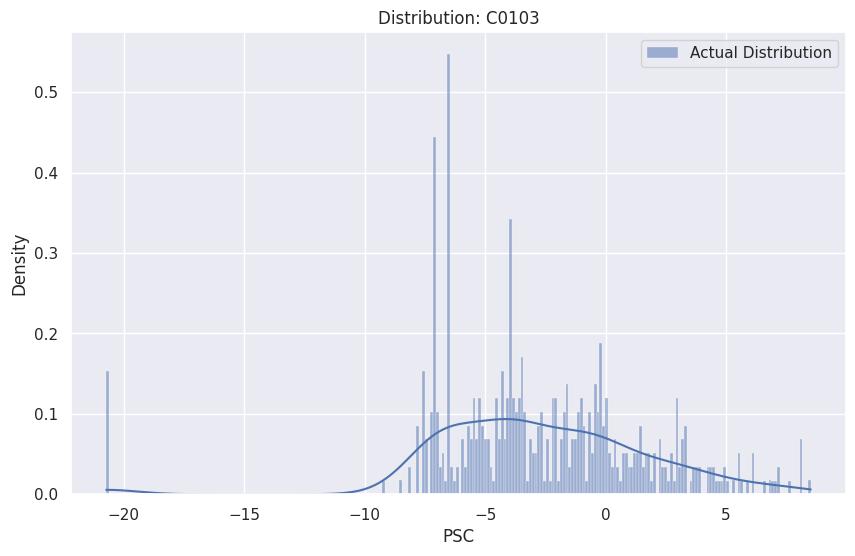

In [17]:
##probability distributions per type of smell
smell_msg_id = 'C0103'
prob_column = 'code_smell_actual_prob_median'
filtered_df = logit_transform_psc(smell_msg_id, prob_column, 4, alignments_df)
plot_density_distribution(smell_msg_id, prob_column+'_trans', filtered_df)